# Load Preprocessed Data

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


# File name
PREPROCESSED_NN_DATA_FILE_NAME = "loan_data_preprocessed_nn.csv"
PREPROCESSED_XGB_DATA_FILE_NAME = "loan_data_preprocessed_xgb.csv"

PROJECT_ROOT = Path("..")
PREPROCESSED_NN_DATA_FILE_PATH = PROJECT_ROOT / "data" / "pre-processed" / PREPROCESSED_NN_DATA_FILE_NAME
PREPROCESSED_XGB_DATA_FILE_PATH = PROJECT_ROOT / "data" / "pre-processed" / PREPROCESSED_XGB_DATA_FILE_NAME

OUTPUT_DIR = PROJECT_ROOT / "data" / "pre-processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Preprocessed NN data path:", PREPROCESSED_NN_DATA_FILE_PATH)
print("Preprocessed XGB data path:", PREPROCESSED_XGB_DATA_FILE_PATH)
print("Output folder:", OUTPUT_DIR)

nn_df = pd.read_csv(PREPROCESSED_NN_DATA_FILE_PATH)
xgb_df = pd.read_csv(PREPROCESSED_XGB_DATA_FILE_PATH)
print(nn_df.shape)
print(xgb_df.shape)
nn_df.head()
xgb_df.head()

PROJECT_ROOT: ..
Preprocessed NN data path: ..\data\pre-processed\loan_data_preprocessed_nn.csv
Preprocessed XGB data path: ..\data\pre-processed\loan_data_preprocessed_xgb.csv
Output folder: ..\data\pre-processed
(44993, 18)
(44993, 13)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,1


# Apply Isolation Forest on Preprocessed NN Data

In [2]:
# Only consider numerical columns for Isolation Forest
nn_features = []
for feature_column in nn_df.select_dtypes(include="number").columns:
    if feature_column != "loan_status":
        nn_features.append(feature_column)

nn_X = nn_df[nn_features].values

nn_isolation_forest_model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
nn_isolation_forest_model.fit(nn_X)

nn_y_predictions = nn_isolation_forest_model.predict(nn_X)
nn_anomaly_scores = nn_isolation_forest_model.decision_function(nn_X)

nn_df["outlier_prediction"] = nn_y_predictions
nn_df["anomaly_score"] = nn_anomaly_scores

print(f"Total samples for preprocessed NN data: {len(nn_y_predictions)}")
print(f"Number of outliers for preprocessed NN data: {(nn_y_predictions == -1).sum()}")

Total samples for preprocessed NN data: 44993
Number of outliers for preprocessed NN data: 2244


# Anomaly Score Distribution of Preprocessed NN Data

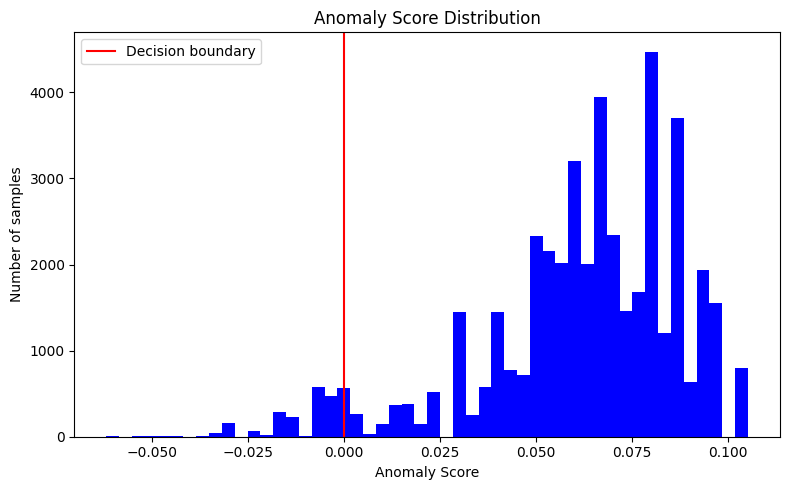

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(nn_anomaly_scores, bins=50, color="blue")
# outlier is less than 0, normal is greater than 0
plt.axvline(0, color="red", linestyle="-", label="Decision boundary")
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of samples")
plt.legend()
plt.tight_layout()
plt.show()

# Apply Isolation Forest on Preprocessed XGB Data

In [4]:
# Only consider numerical columns for Isolation Forest
xgb_features = []
for feature_column in xgb_df.select_dtypes(include="number").columns:
    if feature_column != "loan_status":
        xgb_features.append(feature_column)

xgb_X = xgb_df[xgb_features].values

xgb_isolation_forest_model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
xgb_isolation_forest_model.fit(xgb_X)

xgb_y_predictions = xgb_isolation_forest_model.predict(xgb_X)
xgb_anomaly_scores = xgb_isolation_forest_model.decision_function(xgb_X)

xgb_df["outlier_prediction"] = xgb_y_predictions
xgb_df["anomaly_score"] = xgb_anomaly_scores

print(f"Total samples for preprocessed XGB data: {len(xgb_y_predictions)}")
print(f"Number of outliers for preprocessed XGB data: {(xgb_y_predictions == -1).sum()}")

Total samples for preprocessed XGB data: 44993
Number of outliers for preprocessed XGB data: 2250


# Anomaly Score Distribution of Preprocessed XGB Data

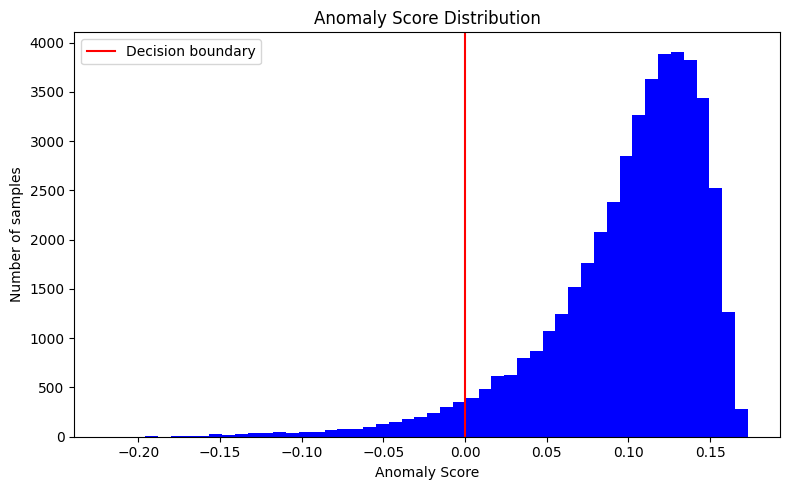

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(xgb_anomaly_scores, bins=50, color="blue")
# outlier is less than 0, normal is greater than 0
plt.axvline(0, color="red", linestyle="-", label="Decision boundary")
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of samples")
plt.legend()
plt.tight_layout()
plt.show()

# Splitting the Preprocessed Dataset into Outliers Only and Normal Datasets

In [6]:
nn_outlier_df = nn_df[nn_df["outlier_prediction"] == -1].drop(columns=["outlier_prediction", "anomaly_score"]).reset_index(drop=True)
nn_normal_df = nn_df[nn_df["outlier_prediction"] == 1].drop(columns=["outlier_prediction", "anomaly_score"]).reset_index(drop=True)

print(f"NN outlier dataset sizes {nn_outlier_df.shape}")
print(f"NN normal dataset sizes {nn_normal_df.shape}")

xgb_outlier_df = xgb_df[xgb_df["outlier_prediction"] == -1].drop(columns=["outlier_prediction", "anomaly_score"]).reset_index(drop=True)
xgb_normal_df = xgb_df[xgb_df["outlier_prediction"] == 1].drop(columns=["outlier_prediction", "anomaly_score"]).reset_index(drop=True)

print(f"XGB outlier dataset sizes {xgb_outlier_df.shape}")
print(f"XGB normal dataset sizes {xgb_normal_df.shape}")


NN outlier dataset sizes (2244, 18)
NN normal dataset sizes (42749, 18)
XGB outlier dataset sizes (2250, 13)
XGB normal dataset sizes (42743, 13)


# Recalculating Anomaly Score Distributions after removing the 5% outliers from both Preprocessed NN and XGB Data

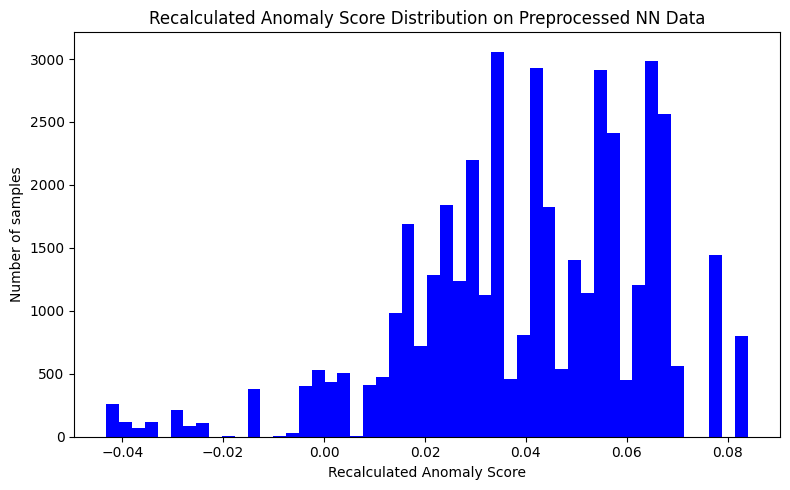

In [7]:
nn_X = nn_normal_df[nn_features].values
nn_isolation_forest_model.fit(nn_X)
nn_anomaly_scores = nn_isolation_forest_model.decision_function(nn_X)

plt.figure(figsize=(8, 5))
plt.hist(nn_anomaly_scores, bins=50, color="blue")
# outlier is less than 0, normal is greater than 0
plt.title("Recalculated Anomaly Score Distribution on Preprocessed NN Data")
plt.xlabel("Recalculated Anomaly Score")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

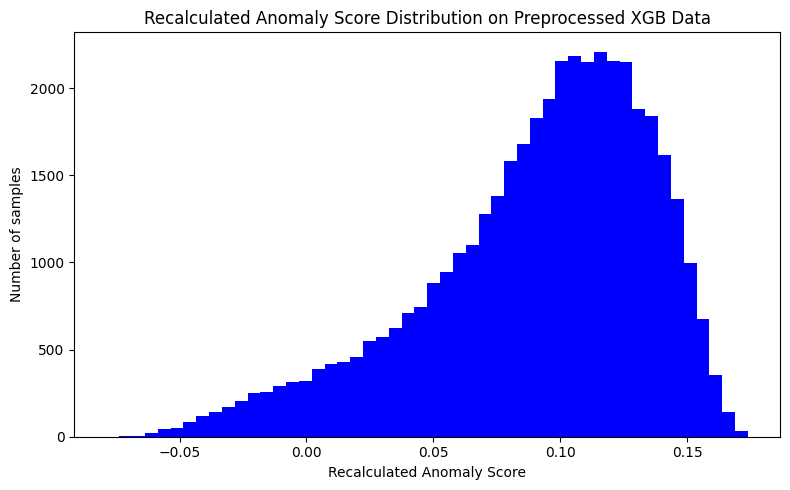

In [8]:
xgb_X = xgb_normal_df[xgb_features].values
xgb_isolation_forest_model.fit(xgb_X)
xgb_anomaly_scores = xgb_isolation_forest_model.decision_function(xgb_X)

plt.figure(figsize=(8, 5))
plt.hist(xgb_anomaly_scores, bins=50, color="blue")
# outlier is less than 0, normal is greater than 0
plt.title("Recalculated Anomaly Score Distribution on Preprocessed XGB Data")
plt.xlabel("Recalculated Anomaly Score")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

# Save splitted preprocessed CSV files

In [9]:
nn_outlier_output_path = OUTPUT_DIR / "loan_data_preprocessed_nn_outlier.csv"
nn_normal_output_path = OUTPUT_DIR / "loan_data_preprocessed_nn_normal.csv"

nn_outlier_df.to_csv(nn_outlier_output_path, index=False)
nn_normal_df.to_csv(nn_normal_output_path, index=False)

print("Saved Neural Network outlier data to:", nn_outlier_output_path)
print("Saved Neural Network normal data to:", nn_normal_output_path)

xgb_outlier_output_path = OUTPUT_DIR / "loan_data_preprocessed_xgb_outlier.csv"
xgb_normal_output_path = OUTPUT_DIR / "loan_data_preprocessed_xgb_normal.csv"

xgb_outlier_df.to_csv(xgb_outlier_output_path, index=False)
xgb_normal_df.to_csv(xgb_normal_output_path, index=False)

print("Saved XGBoost outlier data to:", xgb_outlier_output_path)
print("Saved XGBoost normal data to:", xgb_normal_output_path)

Saved Neural Network outlier data to: ..\data\pre-processed\loan_data_preprocessed_nn_outlier.csv
Saved Neural Network normal data to: ..\data\pre-processed\loan_data_preprocessed_nn_normal.csv
Saved XGBoost outlier data to: ..\data\pre-processed\loan_data_preprocessed_xgb_outlier.csv
Saved XGBoost normal data to: ..\data\pre-processed\loan_data_preprocessed_xgb_normal.csv
